In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

df = pd.read_csv("../data/processed/gspc_features.csv", parse_dates=["Date"], index_col="Date")
df.head()

Matplotlib is building the font cache; this may take a moment.


,Close,High,Low,Open,Volume,log_return,realized_vol_21d,parkinson_vol_21d,garman_klass_vol_21d,regime
Date,,,,,,,,,,
2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000,NaN,NaN,NaN,NaN,normal
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000,-0.018447,NaN,NaN,NaN,normal
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000,-0.008933,NaN,NaN,NaN,normal
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000,0.011563,NaN,NaN,NaN,normal
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000,0.017730,NaN,NaN,NaN,normal


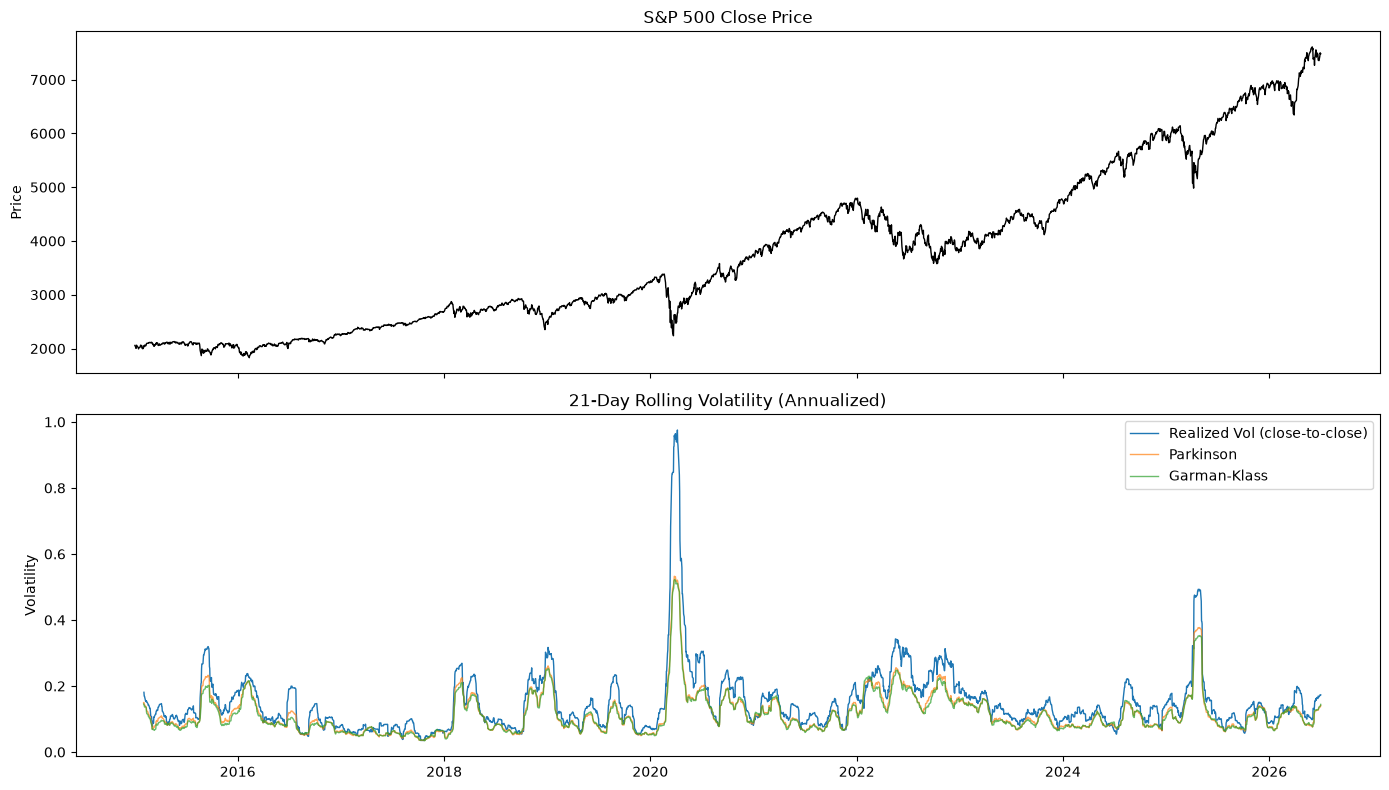

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["Close"], color="black", linewidth=1)
axes[0].set_title("S&P 500 Close Price")
axes[0].set_ylabel("Price")

axes[1].plot(df.index, df["realized_vol_21d"], label="Realized Vol (close-to-close)", linewidth=1)
axes[1].plot(df.index, df["parkinson_vol_21d"], label="Parkinson", linewidth=1, alpha=0.7)
axes[1].plot(df.index, df["garman_klass_vol_21d"], label="Garman-Klass", linewidth=1, alpha=0.7)
axes[1].set_title("21-Day Rolling Volatility (Annualized)")
axes[1].set_ylabel("Volatility")
axes[1].legend()

plt.tight_layout()
plt.show()

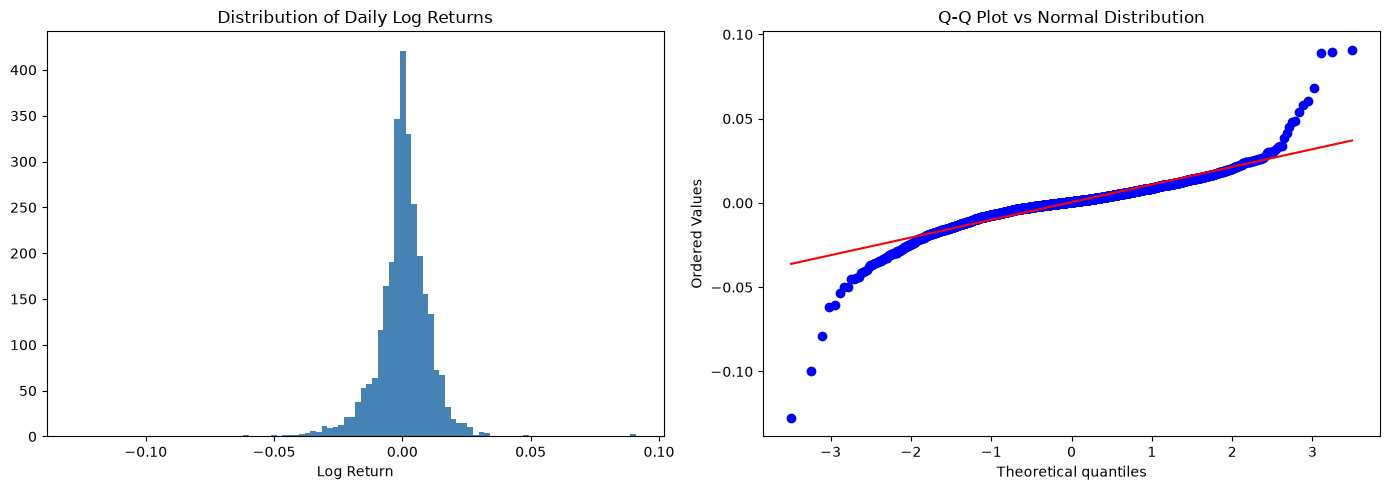

Skewness: -0.647
Kurtosis: 15.799  (normal distribution = 0)


In [3]:
# Histogram: real returns should look roughly bell-shaped but with a visibly sharper peak and longer tails than a true normal distribution — this is the well-known "fat tails" property of financial returns.
# Q-Q plot: if returns were perfectly normal, points would follow the diagonal line exactly. Real financial returns typically curve away from the line at both ends — that curving is the visual signature of fat tails.
# Kurtosis: a normal distribution has kurtosis of 0 (using the "excess kurtosis" convention, which pandas uses by default). Financial returns typically show kurtosis well above 0 (often 5–15+ for daily equity returns) — meaning extreme moves happen far more often than a normal distribution would predict.
# Skewness: equity returns are often slightly negatively skewed (crashes are sharper/faster than rallies).

##### GARCH explicitly model fat-tailed, clustered volatility, unlike a naive constant-variance assumption

returns = df["log_return"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(returns, bins=100, color="steelblue", edgecolor="none")
axes[0].set_title("Distribution of Daily Log Returns")
axes[0].set_xlabel("Log Return")

from scipy import stats
stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot vs Normal Distribution")

plt.tight_layout()
plt.show()

print(f"Skewness: {returns.skew():.3f}")
print(f"Kurtosis: {returns.kurtosis():.3f}  (normal distribution = 0)")

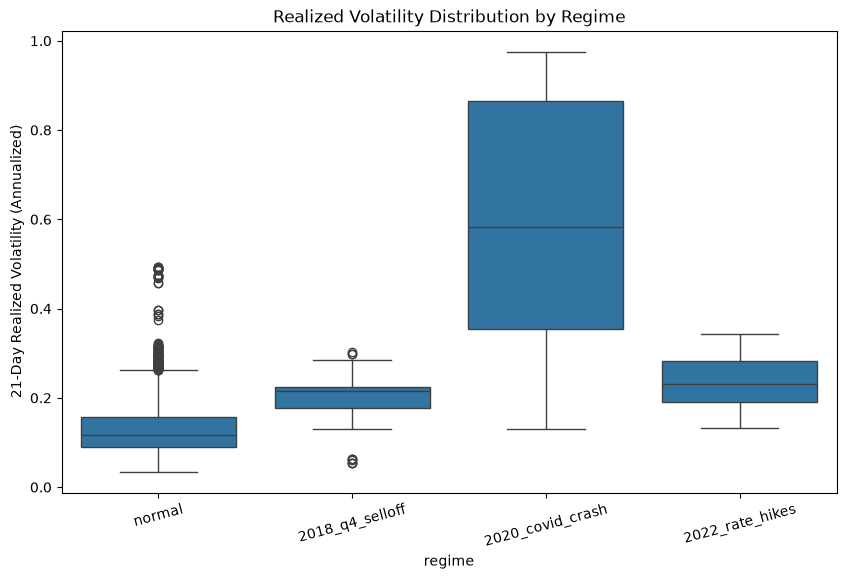

In [5]:
import seaborn as sns

plt.figure(figsize=(10, 6))
regime_order = ["normal", "2018_q4_selloff", "2020_covid_crash", "2022_rate_hikes"]
sns.boxplot(data=df, x="regime", y="realized_vol_21d", order=regime_order)
plt.title("Realized Volatility Distribution by Regime")
plt.ylabel("21-Day Realized Volatility (Annualized)")
plt.xticks(rotation=15)
plt.show()